#Import Data + Modules

In [2]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/final_training.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00
Mounted at /content/drive


#Explanatory Data Analysis

In [3]:
print("Dataset Shape: ", df.shape)
print("Column Names and Types: ", df.dtypes)

df.head()

df.describe()

Dataset Shape:  (88920, 23)
Column Names and Types:  ViewYN                         bool
PoolPrivateYN                  bool
CloseDate                    object
ClosePrice                  float64
Latitude                    float64
Longitude                   float64
LivingArea                  float64
CountyOrParish               object
AttachedGarageYN               bool
ParkingTotal                float64
YearBuilt                   float64
BathroomsTotalInteger       float64
City                         object
BedroomsTotal               float64
ContractStatusChangeDate     object
PurchaseContractDate         object
ListingContractDate          object
FireplaceYN                    bool
Stories                     float64
NewConstructionYN              bool
GarageSpaces                float64
PostalCode                   object
PropertyAgeAtClose          float64
dtype: object


,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,Stories,GarageSpaces,PropertyAgeAtClose
count,8.892000e+04,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000,88920.000000
mean,1.204629e+06,34.732540,-118.618400,2021.562304,3.196294,1975.691284,2.609222,3.480398,1.313237,2.416183,49.308716
std,9.660035e+05,1.715307,3.050863,941.420958,63.573190,27.529159,1.083982,0.958605,0.463812,63.473508,27.529159
min,1.900000e+05,0.000000,-124.193201,0.000000,-35.000000,1776.000000,0.000000,0.000000,1.000000,0.000000,-1.000000
25%,6.300000e+05,33.760679,-119.159296,1386.000000,2.000000,1956.000000,2.000000,3.000000,1.000000,2.000000,27.000000
50%,8.990000e+05,34.080067,-118.026054,1812.000000,2.000000,1976.000000,2.000000,3.000000,1.000000,2.000000,49.000000
75%,1.429006e+06,34.755353,-117.261510,2421.000000,3.000000,1998.000000,3.000000,4.000000,2.000000,2.000000,69.000000
max,8.500000e+06,41.894714,329.000000,14168.000000,15720.000000,2026.000000,45.000000,45.000000,2.000000,15720.000000,249.000000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if not missing_df.empty:
    print("Columns with Missing Values:")
    display(missing_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percentage'], color='coral')
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values by Column (%)")
    plt.ylabel("Percentage Missing")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected!")

No missing values detected!


In [5]:
print("ClosePrice Statistics")
print(df['ClosePrice'].describe())

ClosePrice Statistics
count    8.892000e+04
mean     1.204629e+06
std      9.660035e+05
min      1.900000e+05
25%      6.300000e+05
50%      8.990000e+05
75%      1.429006e+06
max      8.500000e+06
Name: ClosePrice, dtype: float64


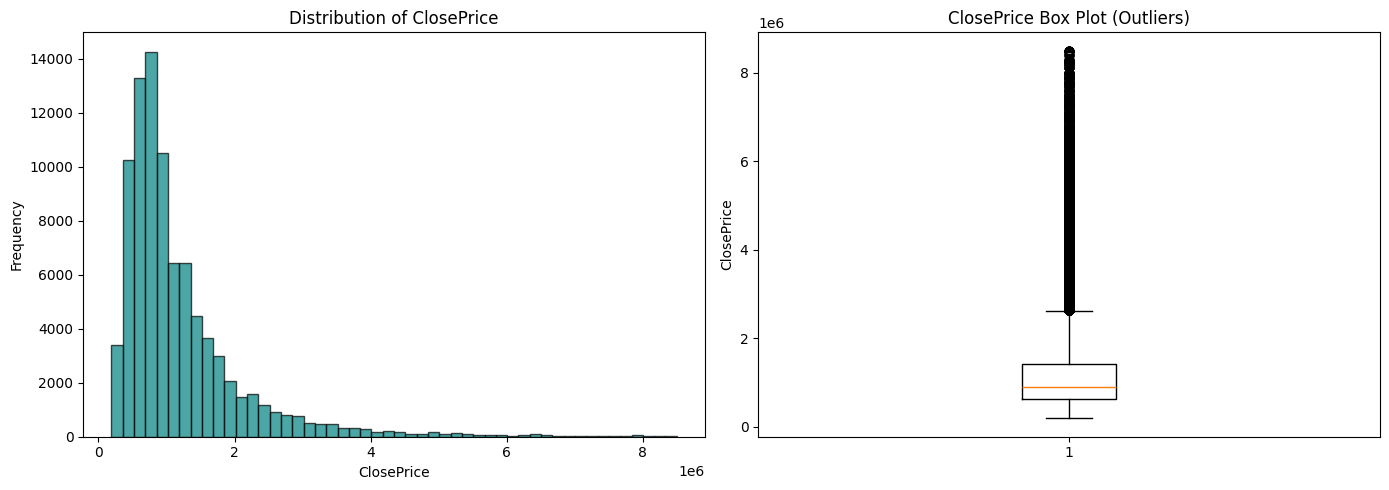

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ClosePrice'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of ClosePrice")
axes[0].set_xlabel("ClosePrice")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df['ClosePrice'], vert=True)
axes[1].set_title("ClosePrice Box Plot (Outliers)")
axes[1].set_ylabel("ClosePrice")

plt.tight_layout()
plt.show()

In [7]:
skew_val = df["ClosePrice"].skew()
print("Skewness: {skew_val:.2f}")
if skew_val > 1:
    print("Highly right-skewed – consider log transformation")
elif skew_val < -1:
    print("Left-skewed – may need scaling")
else:
    print("Target distribution looks fairly symmetric")

Skewness: {skew_val:.2f}
Highly right-skewed – consider log transformation


Top 10 Correlations with ClosePrice:


,ClosePrice
ClosePrice,1.000000
LivingArea,0.601819
BathroomsTotalInteger,0.550734
BedroomsTotal,0.342588
Stories,0.139890
PropertyAgeAtClose,0.010397
ParkingTotal,0.002576
Latitude,0.001731
GarageSpaces,0.001245
YearBuilt,-0.010397


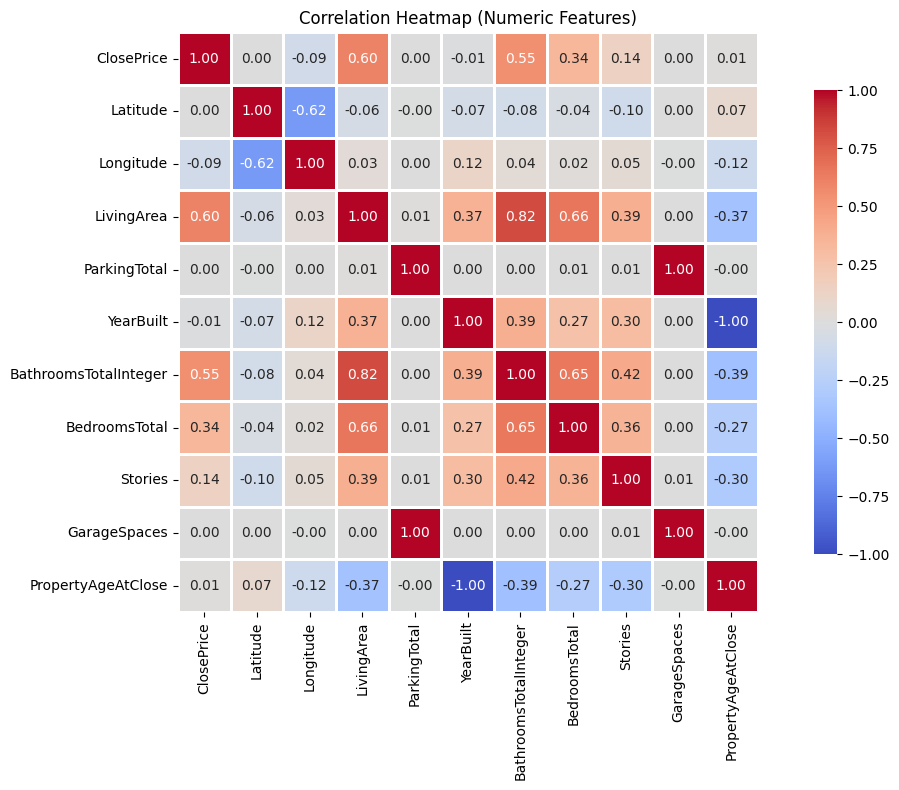

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'ClosePrice' in num_cols:
    corr_with_target = df[num_cols].corr()['ClosePrice'].sort_values(ascending=False)
    print("Top 10 Correlations with ClosePrice:")
    display(corr_with_target.head(10))

    # Correlation heatmap
    plt.figure(figsize=(12, 8))
    corr_matrix = df[num_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

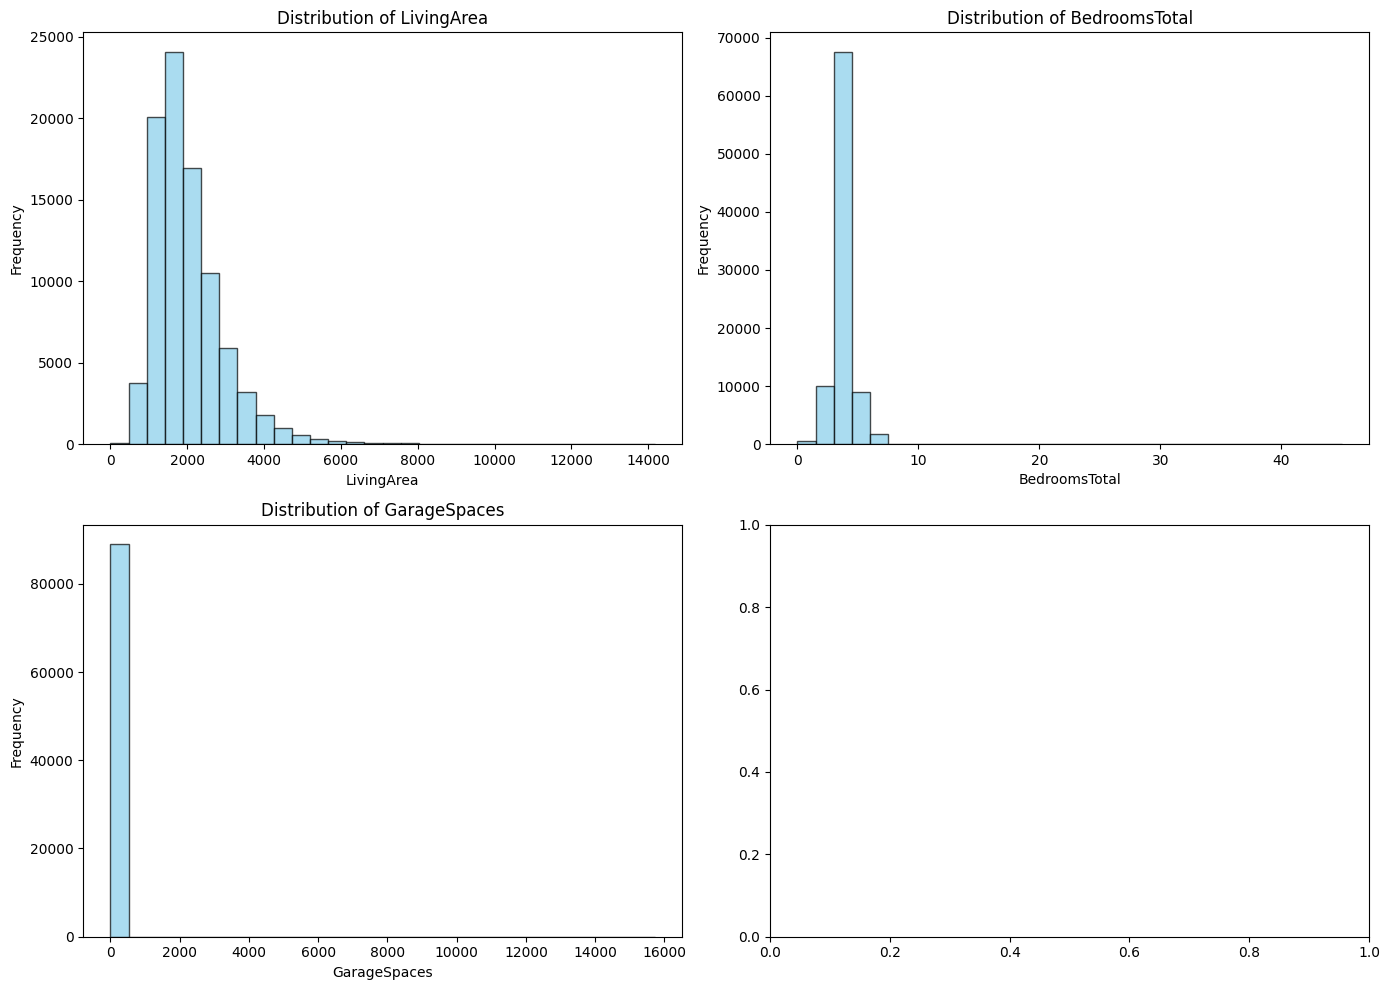

In [9]:
key_features = ["LivingArea", "BedroomsTotal", "BathroomsTotal", "GarageSpaces"]
existing_features = [f for f in key_features if f in df.columns]

if existing_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feat in enumerate(existing_features):
        if i < 4:
            axes[i].hist(df[feat].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            axes[i].set_title(f"Distribution of {feat}")
            axes[i].set_xlabel(feat)
            axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

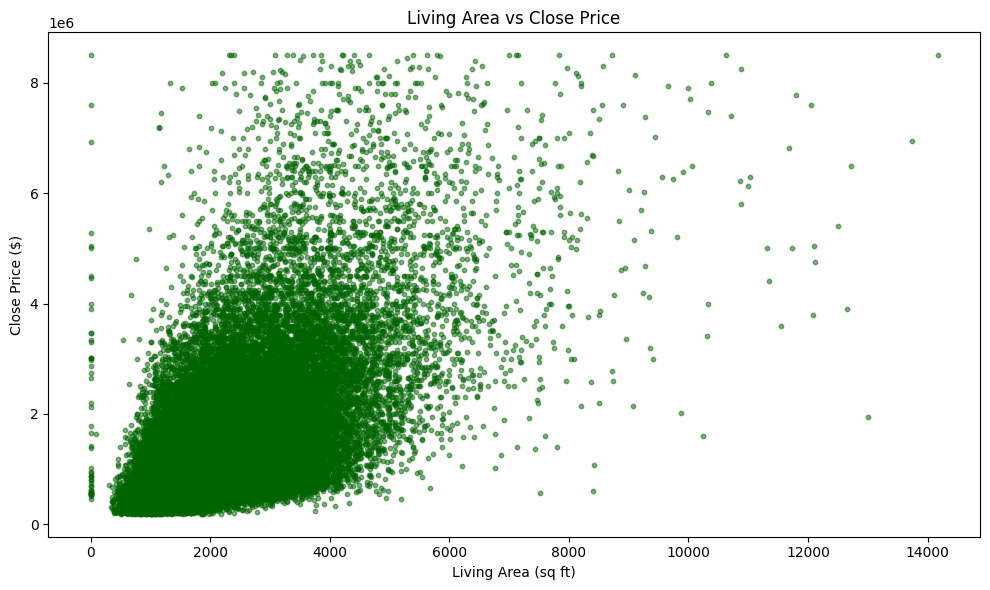

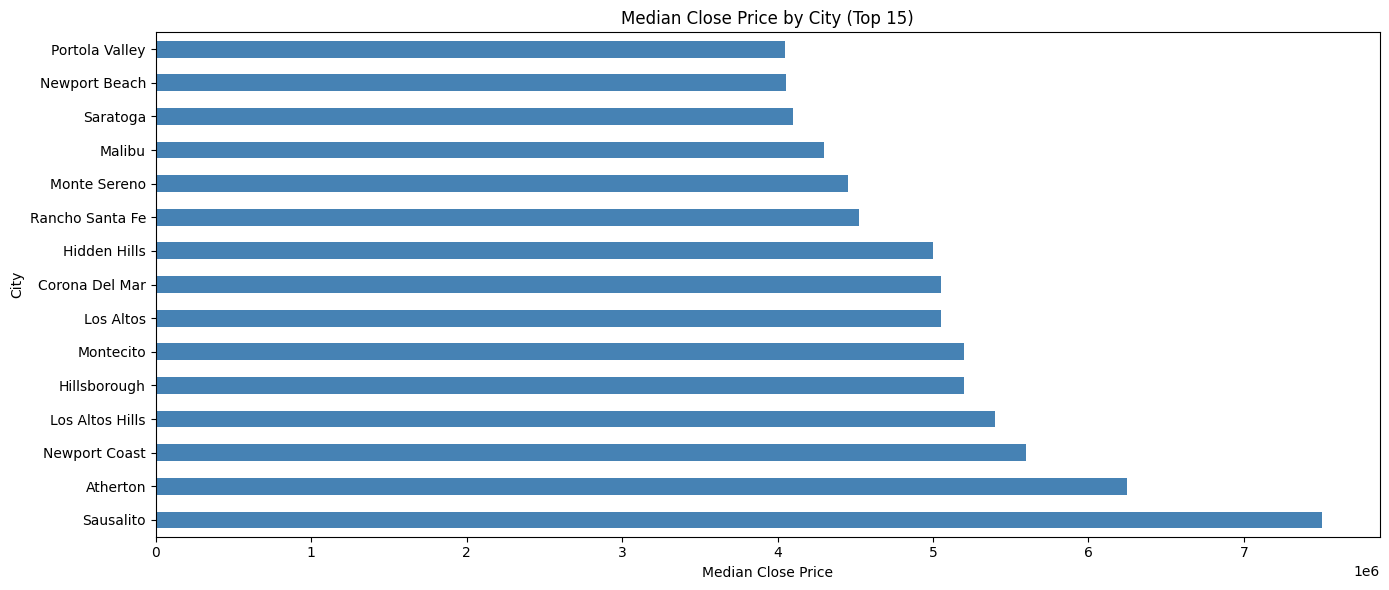

In [10]:
if "LivingArea" in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df["LivingArea"], df["ClosePrice"], alpha=0.5, s=10, color='darkgreen')
    plt.title("Living Area vs Close Price")
    plt.xlabel("Living Area (sq ft)")
    plt.ylabel("Close Price ($)")
    plt.tight_layout()
    plt.show()

if "City" in df.columns:
    plt.figure(figsize=(14, 6))
    city_avg = df.groupby("City")["ClosePrice"].median().sort_values(ascending=False).head(15)
    city_avg.plot(kind='barh', color='steelblue')
    plt.title("Median Close Price by City (Top 15)")
    plt.xlabel("Median Close Price")
    plt.tight_layout()
    plt.show()

#Feature Engieering

In [11]:
# Convert date columns to datetime
date_cols = ["CloseDate", "ContractStatusChangeDate", "PurchaseContractDate", "ListingContractDate"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Create time-based features
if "CloseDate" in df.columns and "ListingContractDate" in df.columns:
    df["DaysOnMarket"] = (df["CloseDate"] - df["ListingContractDate"]).dt.days

if "CloseDate" in df.columns and "PurchaseContractDate" in df.columns:
    df["ContractToCloseDays"] = (df["CloseDate"] - df["PurchaseContractDate"]).dt.days

if "CloseDate" in df.columns:
    df["YearClosed"] = df["CloseDate"].dt.year
    df["MonthClosed"] = df["CloseDate"].dt.month

# Create ratio features
if "BathroomsTotal" in df.columns and "BedroomsTotal" in df.columns:
    df["BathroomsPerBedroom"] = df["BathroomsTotalInteger"] / (df["BedroomsTotal"] + 1e-5)

if "GarageSpaces" in df.columns and "LivingArea" in df.columns:
    df["GarageSpacesPerSqFt"] = df["GarageSpaces"] / (df["LivingArea"] + 1e-5)

# Handle infinities and NaNs from feature engineering
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print("Feature engineering complete!")
print(f" New shape: {df.shape}")

Feature engineering complete!
 New shape: (88920, 28)


In [12]:
# Add polynomial features for key numeric variables
if "LivingArea" in df.columns:
    df["LivingArea_squared"] = df["LivingArea"] ** 2
    df["LivingArea_log"] = np.log1p(df["LivingArea"])

if "LivingArea" in df.columns and "BedroomsTotal" in df.columns:
    df["SqFtPerBedroom"] = df["LivingArea"] / (df["BedroomsTotal"] + 1)

if "LivingArea" in df.columns and "BathroomsTotalInteger" in df.columns:
    df["SqFtPerBathroom"] = df["LivingArea"] / (df["BathroomsTotalInteger"] + 1)

# Property age features
if "PropertyAgeAtClose" in df.columns:
    df["IsNewConstruction"] = (df["PropertyAgeAtClose"] < 5).astype(int)
    df["PropertyAge_squared"] = df["PropertyAgeAtClose"] ** 2

print("Advanced features created!")

Advanced features created!


#Model Training

In [13]:
# Prepare data
target = "ClosePrice"
drop_cols = ["ClosePrice", "CloseDate", "ContractStatusChangeDate",
             "PurchaseContractDate", "ListingContractDate"]
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

# LOG TRANSFORM TARGET (handles skewness!)
y_log = np.log1p(y)

# Identify categorical features
cat_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

# Split data
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Keep original y_test for evaluation
_, _, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Further split training into train/validation for early stopping
X_tr, X_val, y_tr_log, y_val_log = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

print(f" Training set: {X_tr.shape}")
print(f" Validation set: {X_val.shape}")
print(f" Test set: {X_test.shape}")
print(f"Using LOG-TRANSFORMED target to handle skewness")

 Training set: (56908, 29)
 Validation set: (14228, 29)
 Test set: (17784, 29)
Using LOG-TRANSFORMED target to handle skewness


In [14]:
print("Training CatBoost with early stopping...")

cb_params = {
    'cat_features': cat_features,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 8,
    'l2_leaf_reg': 3.0,
    'random_strength': 0.5,
    'bagging_temperature': 0.75,
    'rsm': 0.9,
    'leaf_estimation_iterations': 10,
    'od_type': 'Iter',
    'od_wait': 100,
    'random_state': 42,
    'verbose': 200,
    'use_best_model': True
}

model = CatBoostRegressor(**cb_params)
model.fit(
    X_tr, y_tr_log,
    eval_set=(X_val, y_val_log),
    cat_features=cat_features
)

print(f"Best iteration: {model.best_iteration_}")
print(f"Model trained on LOG scale successfully!")

Training CatBoost with early stopping...
0:	learn: 0.6158922	test: 0.6170668	best: 0.6170668 (0)	total: 466ms	remaining: 38m 50s
200:	learn: 0.2109178	test: 0.2018178	best: 0.2018178 (200)	total: 29.8s	remaining: 11m 51s
400:	learn: 0.1881932	test: 0.1848253	best: 0.1848253 (400)	total: 52.2s	remaining: 9m 58s
600:	learn: 0.1765128	test: 0.1782629	best: 0.1782629 (600)	total: 1m 14s	remaining: 9m 2s
800:	learn: 0.1683327	test: 0.1744745	best: 0.1744745 (800)	total: 1m 37s	remaining: 8m 31s
1000:	learn: 0.1617345	test: 0.1719765	best: 0.1719765 (1000)	total: 1m 59s	remaining: 7m 58s
1200:	learn: 0.1562551	test: 0.1701328	best: 0.1701328 (1200)	total: 2m 24s	remaining: 7m 36s
1400:	learn: 0.1515817	test: 0.1688005	best: 0.1688005 (1400)	total: 2m 48s	remaining: 7m 11s
1600:	learn: 0.1474490	test: 0.1679587	best: 0.1679577 (1599)	total: 3m 9s	remaining: 6m 42s
1800:	learn: 0.1436446	test: 0.1672399	best: 0.1672399 (1800)	total: 3m 33s	remaining: 6m 19s
2000:	learn: 0.1401517	test: 0.16653


📊 Test Set Performance (LOG-TRANSFORMED MODEL):
MAE:   $155,625.21
RMSE:  $321,676.40
R²:    0.8887
MAPE:  11.60%


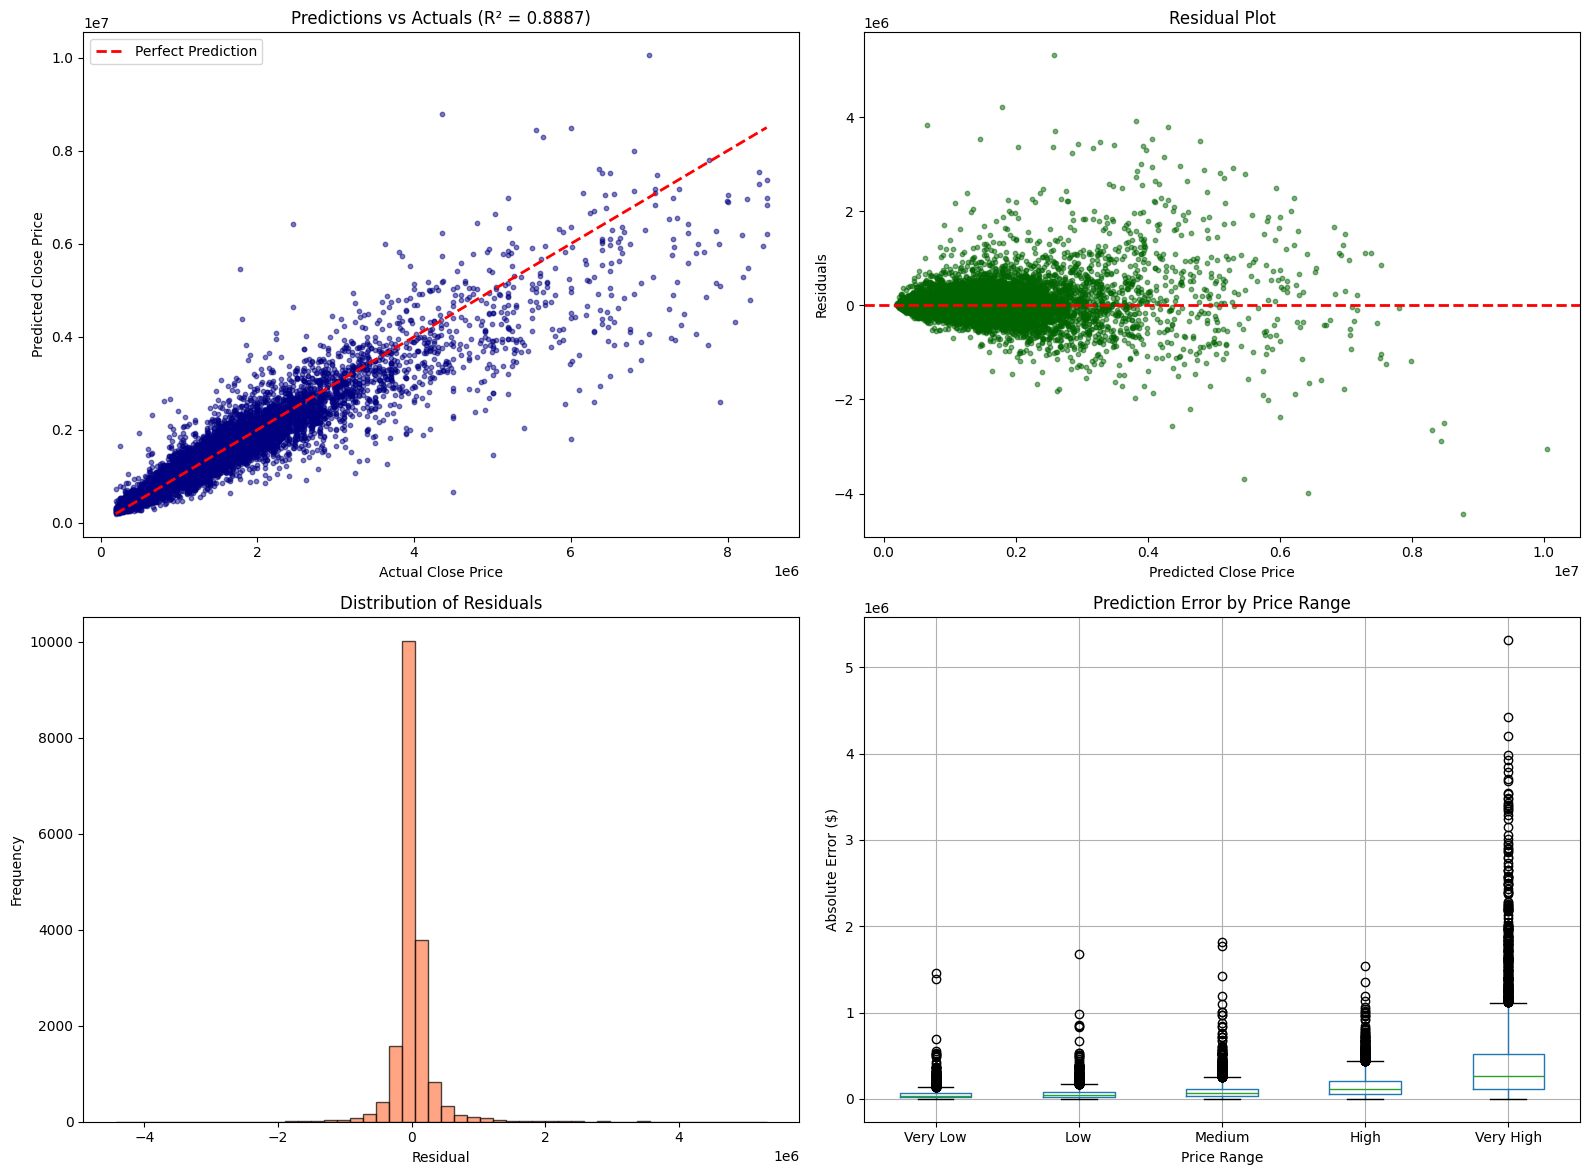

First 10 Test Predictions:


,Actual,Predicted,Error,Error_Pct
0,1154000.0,1.106631e+06,47368.531460,4.104725
1,2950000.0,2.452339e+06,497661.349990,16.869876
2,2585000.0,2.224297e+06,360703.078278,13.953697
3,615000.0,5.909381e+05,24061.896699,3.912504
4,575000.0,9.740558e+05,-399055.764826,-69.401003
5,395000.0,3.903667e+05,4633.259997,1.172977
6,550000.0,5.181828e+05,31817.167159,5.784939
7,1025000.0,8.870810e+05,137919.034817,13.455516
8,1075000.0,1.181035e+06,-106034.941606,-9.863715
9,1200000.0,6.965529e+05,503447.079064,41.953923


Top 15 Most Important Features:


,Feature Id,Importances
0,City,17.316297
1,CountyOrParish,14.609628
2,Latitude,12.107615
3,Longitude,11.423923
4,LivingArea_log,7.908564
5,PostalCode,6.421927
6,LivingArea,4.110371
7,LivingArea_squared,4.107520
8,BathroomsTotalInteger,3.203432
9,SqFtPerBedroom,2.666341


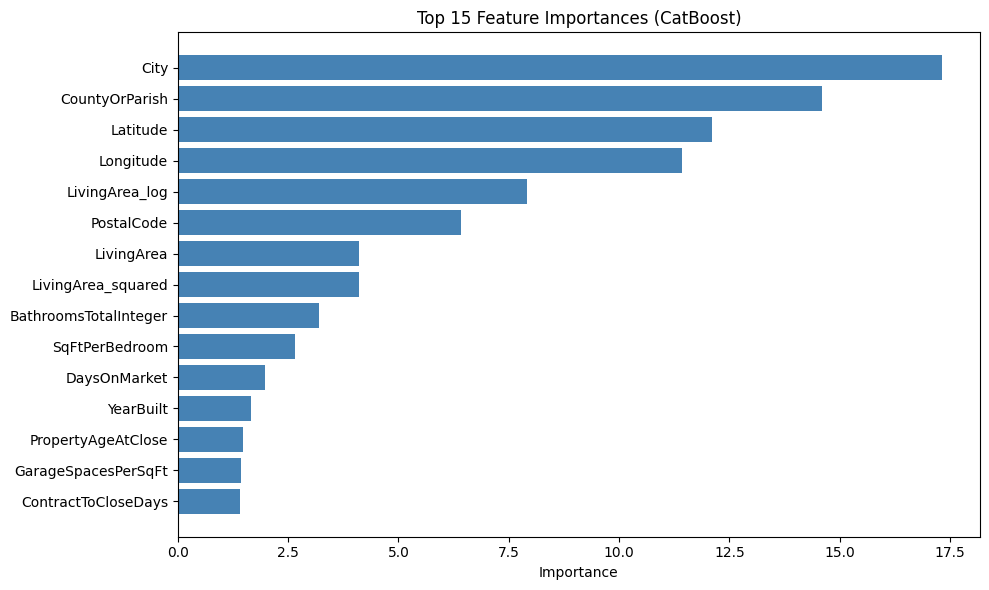

In [15]:
# Get predictions on LOG scale, then transform back to original scale
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n📊 Test Set Performance (LOG-TRANSFORMED MODEL):")
print(f"MAE:   ${mae:,.2f}")
print(f"RMSE:  ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")
print(f"MAPE:  {mape:.2f}%")

# Calculate residuals
residuals = y_test - y_pred

# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predictions vs Actual
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=10, color='navy')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel("Actual Close Price")
axes[0, 0].set_ylabel("Predicted Close Price")
axes[0, 0].set_title(f"Predictions vs Actuals (R² = {r2:.4f})")
axes[0, 0].legend()

# 2. Residual plot
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=10, color='darkgreen')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel("Predicted Close Price")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residual Plot")

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Distribution of Residuals")

# 4. Error by price range
price_ranges = pd.qcut(y_test, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_by_range = pd.DataFrame({
    'Range': price_ranges,
    'Absolute_Error': np.abs(residuals)
})
error_by_range.boxplot(column='Absolute_Error', by='Range', ax=axes[1, 1])
axes[1, 1].set_xlabel("Price Range")
axes[1, 1].set_ylabel("Absolute Error ($)")
axes[1, 1].set_title("Prediction Error by Price Range")
plt.suptitle("")  # Remove the automatic title

plt.tight_layout()
plt.show()

# Show predictions for a sample
sample_results = pd.DataFrame({
    'Actual': y_test.head(10).values,
    'Predicted': y_pred[:10],
    'Error': residuals.head(10).values,
    'Error_Pct': (residuals.head(10) / y_test.head(10) * 100).values
})
print("First 10 Test Predictions:")
display(sample_results)

feature_importances = model.get_feature_importance(prettified=True)
top_features = feature_importances.head(15)

print("Top 15 Most Important Features:")
display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature Id'], top_features['Importances'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [16]:
# After model training, before test evaluation:

# Get training predictions
y_train_pred_log = model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)

# Calculate training metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
train_mdape = np.median(np.abs((y_train - y_train_pred) / y_train)) * 100

print(f"Training R²: {train_r2:.4f}")
print(f"Training MAPE: {train_mape:.2f}%")
print(f"Training MdAPE: {train_mdape:.2f}%")

# Then your existing test metrics
test_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
test_mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Testing R²: {r2:.4f}")
print(f"Testing MAPE: {test_mape:.2f}%")
print(f"Testing MdAPE: {test_mdape:.2f}%")

Training R²: 0.9391
Training MAPE: 9.06%
Training MdAPE: 6.57%
Testing R²: 0.8887
Testing MAPE: 11.60%
Testing MdAPE: 8.03%
